In [54]:
import pandas as pd

df=pd.read_csv('../data/processed/sample_50k.csv')

df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words
0,8067,15738,15739,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0,34,34,8,8,7
1,368101,12736,104117,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...,0,53,51,11,9,6
2,70497,121486,121487,Which is more advisable and better material fo...,What is the best server setup for buddypress?,0,96,45,16,8,2
3,226567,254474,258192,How do I improve logical programming skills?,How can I improve my logical skills for progra...,1,44,52,7,9,4
4,73186,48103,3062,How close we are to see 3rd world war?,How close is a World War III?,1,38,29,9,7,3


### making it lowercase

In [55]:
def lower_text(text):
    return str(text).lower()

In [56]:
df['question1']=df['question1'].apply(lower_text)
df['question2']=df['question2'].apply(lower_text)

In [57]:
df[['question1','question2']].head()

,question1,question2
0,how do i play pokémon go in korea?,how do i play pokémon go in china?
1,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...
2,which is more advisable and better material fo...,what is the best server setup for buddypress?
3,how do i improve logical programming skills?,how can i improve my logical skills for progra...
4,how close we are to see 3rd world war?,how close is a world war iii?


# Stemming

In [58]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [59]:
def stem_text(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

In [60]:
df['question1'] = df['question1'].apply(stem_text)
df['question2'] = df['question2'].apply(stem_text)

### Remove Punctuation

In [61]:
import re

def remove_punctuation(text):
    return re.sub(r'[^\w\s]',"",text)


    #syntax re.sub(pattern, replacement, string)

In [62]:
df['question1']=df['question1'].apply(remove_punctuation)
df['question2']=df['question2'].apply(remove_punctuation)

### Total Unique words

In [63]:
def total_words(q1,q2):
    w1=set(str(q1).split())
    w2=set(str(q2).split())

    return len(w1.union(w2))

In [64]:
df['total_unique_words']=df.apply(
    lambda row:
    total_words(
        row['question1'],
        row['question2']
    ),
    axis=1
    
)

In [65]:
df['word_share']=(
    df['common_words']/df['total_unique_words']
)

### Length differnce

In [66]:
df['len_diff']=abs(df['q1_len']-df['q2_len'])

## Visualisation


minimum characters  1
maximum characters 430


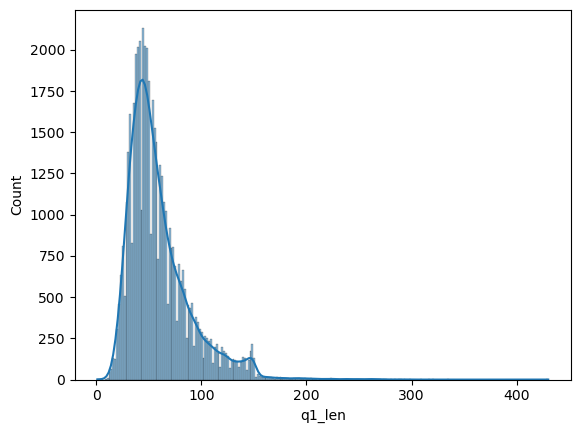

In [67]:
import seaborn as sns
sns.histplot(df['q1_len'],kde=True)
print('minimum characters ',df['q1_len'].min())
print('maximum characters',df['q1_len'].max())



minimum characters 1
maximum characters 1169
average num of characters 59


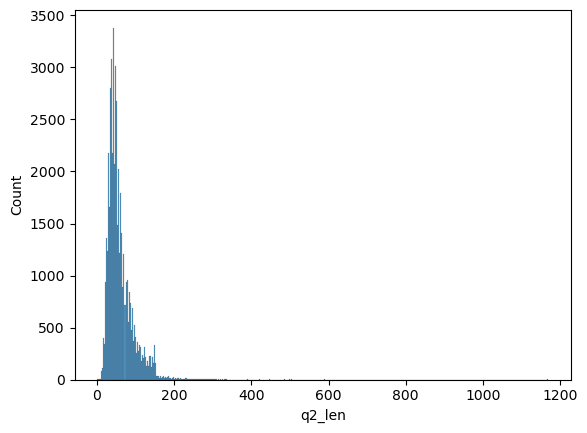

In [68]:
sns.histplot(df['q2_len'])
print('minimum characters',df['q2_len'].min())
print('maximum characters',df['q2_len'].max())
print('average num of characters',int(df['q2_len'].mean()))


minimum no of words in q1 1
maximum no of words in q1 80
average num of words 10


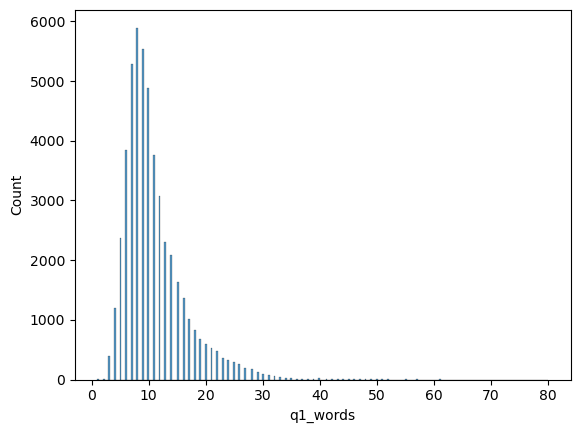

In [69]:
sns.histplot(df['q1_words'])
print("minimum no of words in q1",df['q1_words'].min())
print("maximum no of words in q1",df['q1_words'].max())
print('average num of words',int(df['q1_words'].mean()))

minimum no of words in q2 1
maximum no of words in q2 228
average num of words 11


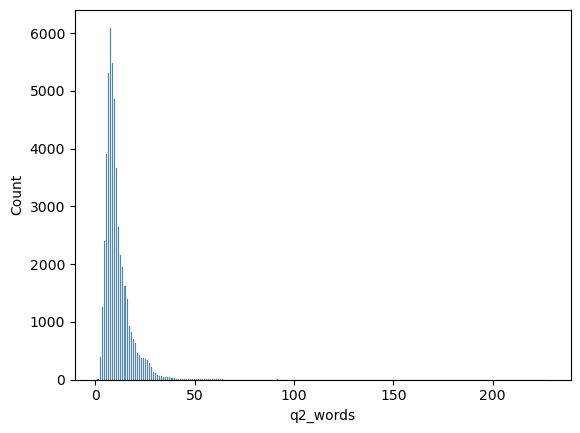

In [70]:
sns.histplot(df['q2_words'])
print("minimum no of words in q2",df['q2_words'].min())
print("maximum no of words in q2",df['q2_words'].max())
print('average num of words',int(df['q2_words'].mean()))

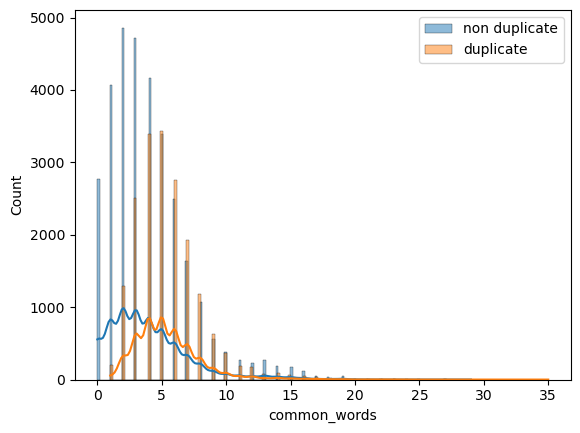

In [71]:
import matplotlib.pyplot as plt

sns.histplot(df[df['is_duplicate']==0]['common_words'],label='non duplicate',kde=True)
sns.histplot(df[df['is_duplicate']==1]['common_words'],label='duplicate',kde=True)

plt.legend()
plt.show()

In [72]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,total_unique_words,word_share,len_diff
0,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,34,34,8,8,7,9,0.777778,0
1,368101,12736,104117,what are some of the best side dish for crab c...,what are some good side dish for buffalo chicken,0,53,51,11,9,6,14,0.428571,2
2,70497,121486,121487,which is more advis and better materi for a cr...,what is the best server setup for buddypress,0,96,45,16,8,2,22,0.090909,51
3,226567,254474,258192,how do i improv logic program skills,how can i improv my logic skill for programming,1,44,52,7,9,4,12,0.333333,8
4,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,38,29,9,7,3,12,0.250000,9


C:\Users\INDIA\AppData\Local\Temp\ipykernel_3564\1607306682.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['is_duplicate'] == 0]['word_share'],label='non duplicate')
C:\Users\INDIA\AppData\Local\Temp\ipykernel_3564\1607306682.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['

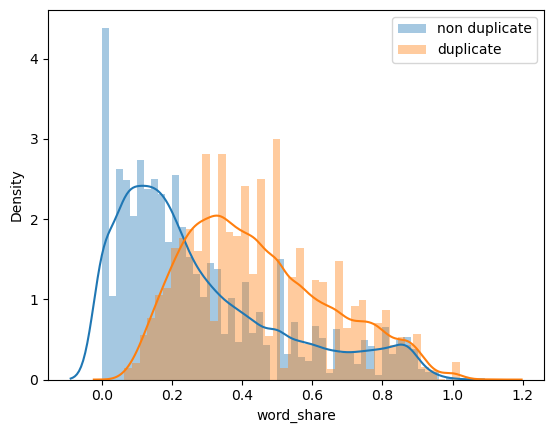

In [73]:
# word share
sns.distplot(df[df['is_duplicate'] == 0]['word_share'],label='non duplicate')
sns.distplot(df[df['is_duplicate'] == 1]['word_share'],label='duplicate')
plt.legend()
plt.show()

In [74]:
!pip install fuzzywuzzy

Defaulting to user installation because normal site-packages is not writeable


In [75]:
from fuzzywuzzy import fuzz

df['fuzz_ratio']=df.apply(
    lambda row:
    fuzz.QRatio(
        row['question1'],
        row['question2']
    ),
    axis=1
)

In [76]:
df['partial_ratio'] = df.apply(
    lambda row:
    fuzz.partial_ratio(
        row['question1'],
        row['question2']
    ),
    axis=1
)

# TF-IDF

In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [84]:
#combine text

questions=list(df['question1'])+list(df['question2'])

In [85]:
#create vectorizer

tfidf=TfidfVectorizer(
    max_features=5000
)

In [86]:
tfidf.fit(questions)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [87]:
q1_tfidf=tfidf.transform(df['question1'])
q2_tfidf=tfidf.transform(df['question2'])

In [88]:
#calculate sine cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
tfidf_cosine_similarity=[]

for i in range(df.shape[0]):
    sim=cosine_similarity(
        q1_tfidf[i],
        q2_tfidf[i]
    )[0][0]

    tfidf_cosine_similarity.append(sim)

#craeting new feature
df['tfidf_cosine_similarity']=tfidf_cosine_similarity

In [89]:
df.groupby('is_duplicate')['tfidf_cosine_similarity'].mean()

is_duplicate
0    0.431026
1    0.646162
Name: tfidf_cosine_similarity, dtype: float64

In [90]:
df.to_csv(
    '../data/processed/final_features.csv',
    index=False
)

In [91]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,total_unique_words,word_share,len_diff,fuzz_ratio,partial_ratio,tfidf_cosine_similarity
0,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,34,34,8,8,7,9,0.777778,0,88,88,0.745125
1,368101,12736,104117,what are some of the best side dish for crab c...,what are some good side dish for buffalo chicken,0,53,51,11,9,6,14,0.428571,2,71,71,0.750571
2,70497,121486,121487,which is more advis and better materi for a cr...,what is the best server setup for buddypress,0,96,45,16,8,2,22,0.090909,51,37,45,0.053934
3,226567,254474,258192,how do i improv logic program skills,how can i improv my logic skill for programming,1,44,52,7,9,4,12,0.333333,8,67,69,0.470717
4,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,38,29,9,7,3,12,0.250000,9,68,61,0.541497


# word2Vec 

In [92]:
!pip install gensim

Defaulting to user installation because normal site-packages is not writeable


In [93]:
sentences = (
    df['question1'].astype(str).apply(lambda x: x.split()).tolist() +
    df['question2'].astype(str).apply(lambda x: x.split()).tolist()
)

In [94]:
#training word to vec model

from gensim.models import Word2Vec

w2v_model=Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

In [95]:
#convert sentence to vectors

import numpy as np

def get_vector(text):
    words=text.split()
    vectors=[]

    for word in words:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    if len(vectors)==0:
        return np.zeros(100)

    return np.mean(vectors,axis=0)

In [96]:
# compute similaritu

def w2v_similarity(q1,q2):
    v1=get_vector(q1)
    v2=get_vector(q2)

    return cosine_similarity([v1],[v2])[0][0]

In [97]:
df['w2v_similarity'] = df.apply(
    lambda row: w2v_similarity(
        row['question1'],
        row['question2']
    ),
    axis=1
)

In [98]:
df.groupby('is_duplicate')['w2v_similarity'].mean()

is_duplicate
0    0.795299
1    0.883763
Name: w2v_similarity, dtype: float64

In [99]:
df.to_csv(
    '../data/processed/final_featuresWord2vec.csv',
    index=False
)

In [100]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,total_unique_words,word_share,len_diff,fuzz_ratio,partial_ratio,tfidf_cosine_similarity,w2v_similarity
0,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,34,34,8,8,7,9,0.777778,0,88,88,0.745125,0.996471
1,368101,12736,104117,what are some of the best side dish for crab c...,what are some good side dish for buffalo chicken,0,53,51,11,9,6,14,0.428571,2,71,71,0.750571,0.927082
2,70497,121486,121487,which is more advis and better materi for a cr...,what is the best server setup for buddypress,0,96,45,16,8,2,22,0.090909,51,37,45,0.053934,0.713124
3,226567,254474,258192,how do i improv logic program skills,how can i improv my logic skill for programming,1,44,52,7,9,4,12,0.333333,8,67,69,0.470717,0.925362
4,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,38,29,9,7,3,12,0.250000,9,68,61,0.541497,0.860121


# saving TF-idf and Word2vec

In [101]:
import pickle

with open('../models/tfidf_vectorizer.pkl','wb') as f:
    pickle.dump(tfidf,f)

print("TF-IDF vectorizer saved")

TF-IDF vectorizer saved


In [102]:
w2v_model.save('../models/w2v_model.model')

print("Word2Vec model saved")

Word2Vec model saved
